# Regression and Time Series

## From Classification to Regression

<div style='text-align:center; padding: 20px 0;'>

| $y \in \{-1,+1\}$ | $y \in \mathbb{R}$ |
|:---:|:---:|
| Classification | **Regression** |

</div>

<div style='text-align:center; margin-top:1em;'>

The most popular and best understood type of regression is  
**linear regression** using a *least-squares cost function*.

</div>

## Linear Regression — Model

<div style='text-align:center;'>

Target variable $y \in \mathbb{R}$ (hand position) is modelled as a **linear combination** of regressors $\mathbf{x} \in \mathbb{R}^N$ (EMG features):

$y = \mathbf{w}^{\top} \mathbf{x}$

In matrix form, with $T$ samples, $\mathbf{y} \in \mathbb{R}^{1 \times T}$, $\mathbf{X} \in \mathbb{R}^{N \times T}$:

$\mathbf{y} = \mathbf{w}^{\top} \mathbf{X}$

<img src='figures/lsq_model.pdf' width='480'/>

</div>

## Linear Regression — Derivation of the Solution

<div style='text-align:center;'>

Expand the least-squares loss:

$$\mathcal{E}_{lsq}(\mathbf{w}) = (\mathbf{y} - \mathbf{w}^{\top}\mathbf{X})^2 $$

</div>

## Linear Regression — Derivation of the Solution

<div style='text-align:center;'>

Expand the least-squares loss:

$$\mathcal{E}_{lsq}(\mathbf{w}) = (\mathbf{y} - \mathbf{w}^{\top}\mathbf{X})^2 = \mathbf{y}\mathbf{y}^{\top} - 2\mathbf{w}^{\top}\mathbf{X}\mathbf{y}^{\top} + \mathbf{w}^{\top}\mathbf{X}\mathbf{X}^{\top}\mathbf{w}$$

Compute derivative w.r.t. $\mathbf{w}$:

$$\dfrac{\partial \mathcal{E}_{lsq}(\mathbf{w})}{\partial \mathbf{w}} = -2\mathbf{X}\mathbf{y}^{\top} + 2\mathbf{X}\mathbf{X}^{\top}\mathbf{w}$$

Set to zero and solve for $\mathbf{w}$:

$$\mathbf{X}\mathbf{X}^{\top}\mathbf{w} = \mathbf{X}\mathbf{y}^{\top}$$

$$\mathbf{w} = \left(\underbrace{\mathbf{X}\mathbf{X}^{\top}}_{\text{Cov. Mat.}}\right)^{-1}\mathbf{X}\mathbf{y}^{\top}$$

</div>

## Linear Regression for Vector Labels

<div style='text-align:center;'>

Prediction of vector-valued labels $\mathbf{y} \in \mathbb{R}^M$  
is called **Multiple Linear Regression (MLR)**.

For a measurement $\mathbf{X} \in \mathbb{R}^{N \times T},\; \mathbf{Y} \in \mathbb{R}^{M \times T}$, the MLR model is:

$$\mathbf{Y} = \mathbf{W}^{\top}\mathbf{X}$$

where $\mathbf{W}^{\top} \in \mathbb{R}^{M \times N}$ is a **linear mapping** from data to labels.

</div>

## Linear Regression for Vector Labels

<div style='text-align:center;'>

Given $\mathbf{X} \in \mathbb{R}^{N \times T}$ and labels $\mathbf{Y} \in \mathbb{R}^{M \times T}$,  
the error function for MLR is:

$$\mathcal{E}_{MLR}(\mathbf{W}) = \displaystyle\sum_{m=1}^{M}\left(\mathbf{Y}_m - \mathbf{W}_m^{\top}\mathbf{X}\right)^2$$

where $\mathbf{Y}_m$ denotes the $m$-th output dimension and $\mathbf{W}_m$ the corresponding weight vector.

The error is minimized by:

$$\mathbf{W} = (\mathbf{X}\mathbf{X}^{\top})^{-1}\mathbf{X}\mathbf{Y}^{\top}$$

</div>

## Correlated Data and Linear Mappings

<div style='text-align:center; font-size:0.85em;'>

We generate uncorrelated data $\mathbf{x} \in \mathbb{R}^2$ drawn from $\mathbf{x} \sim \mathcal{N}(0,1)$.  
Correlations are induced by a diagonal scaling matrix $D$ and a rotation matrix $R$.

<table style='margin:auto; border:none;'>
<tr>
<td style='text-align:center; border:none; padding:0 12px;'>
<b>Uncorrelated</b><br>
<img src='figures/linear_mappings_uncorr.pdf' width='200'/><br>
$\mathbf{x} \sim \mathcal{N}(0,1)$<br>
$\mathbf{X}\mathbf{X}^{\top} = \begin{bmatrix}1&0\\0&1\end{bmatrix}$
</td>
<td style='text-align:center; border:none; padding:0 12px;'>
<b>Uncorrelated, scaled</b><br>
<img src='figures/linear_mappings_scaled.pdf' width='200'/><br>
$\begin{bmatrix}3&0\\0&1\end{bmatrix}\mathbf{X}$<br>
$\mathbf{X}\mathbf{X}^{\top} = \begin{bmatrix}9&0\\0&1\end{bmatrix}$
</td>
<td style='text-align:center; border:none; padding:0 12px;'>
<b>Scaled, rotated by $45^\circ$</b><br>
<img src='figures/linear_mappings_rot-45.pdf' width='200'/><br>
$\scriptsize\begin{bmatrix}\cos\phi & -\sin\phi\\\sin\phi&\cos\phi\end{bmatrix}\begin{bmatrix}3&0\\0&1\end{bmatrix}\mathbf{X}$<br>
$\mathbf{X}\mathbf{X}^{\top} = \begin{bmatrix}5&4\\4&5\end{bmatrix}$
</td>
</tr>
</table>

</div>

## Linear Regression — Pseudocode

**Require:** Data matrix $\mathbf{X} \in \mathbb{R}^{N \times T}$, labels $\mathbf{y} \in \mathbb{R}^{1 \times T}$  
**Ensure:** Weight vector $\mathbf{w}$

```
1. Prepend a row of ones to X          # add bias term
       X_aug = [ ones(1,T) ; X ]       # shape: (N+1) x T

2. Compute covariance matrix
       C = X_aug @ X_aug.T             # shape: (N+1) x (N+1)

3. Compute cross-correlation
       b = X_aug @ y.T                 # shape: (N+1) x 1

4. Solve normal equations
       w = inverse(C) @ b

PREDICT(X_new):
       return w.T @ X_new_aug
```

## Linear Regression for EMG

We simulate the myographic setting:

- **Input $x$:** muscle activation amplitude (rectified EMG envelope)
- **Output $y$:** hand position (degrees of flexion)


## Application: Myoelectric Prosthesis Control

<div style='text-align:center;'>
<table style='margin:auto; border:none;'>
<tr>
<td style='border:none; padding:0 20px; text-align:center; vertical-align:top;'>
<img src='figures/muscles_neurons.png' width='340'/><br>
<small>Neurons activate muscles via electric discharges.<br>Activity measured non-invasively via EMG.</small>
</td>
<td style='border:none; padding:0 20px; text-align:center; vertical-align:top;'>
<img src='figures/prosthesis.png' width='200'/><br>
<small>State-of-the-art hand prosthesis.<br>Controlled by surface EMG signals.</small>
</td>
</tr>
</table>
</div>

## Acquisition of Training Data

<table style='margin:auto; border:none;'>
<tr>
<td style='text-align:center; border:none; padding: 0 20px; vertical-align:top;'>
<img src='figures/experimental_paradigm.pdf' width='380'/><br>
<small>Experimental Paradigm</small>
</td>
<td style='text-align:center; border:none; padding: 0 20px; vertical-align:top;'>
<img src='figures/motion_capture.png' width='180'/><br>
<small>Motion Capture System</small><br><br>
<img src='figures/feedback.png' width='180'/><br>
<small>Visual Feedback</small>
</td>
</tr>
</table>

In [95]:
import pylab as plt
import numpy as np
import scipy as sp

def load_data(fname):
    # load the data
    data = sp.io.loadmat(fname)
    # extract images and labels
    X = np.lib.scimath.log(data['training_data'])
    Y = data['training_labels']
    Xtest = np.lib.scimath.log(data['test_data'])
    return X,Y,Xtest

## Covariance Matrix of EMG Data


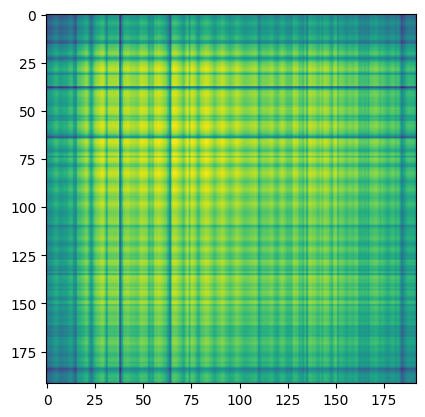

In [111]:
X,Y,Xtest = load_data('myo_data.mat')
plt.imshow(X @ X.T);

In [112]:
X.shape

(192, 1376)

In [113]:
Y.shape

(2, 1376)

## Target Variables

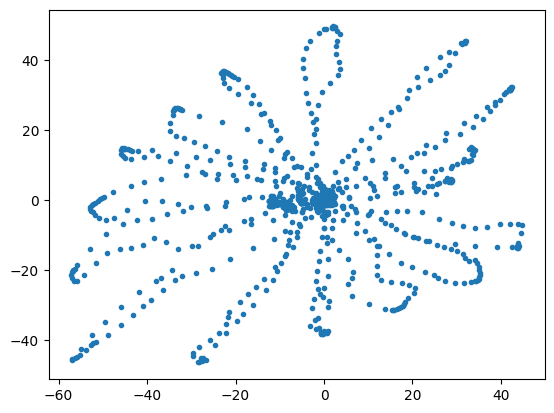

In [100]:
plt.plot(Y[0,:1000],Y[1,:1000],'.');

## EMG Decoding Example
Which movement was performed?

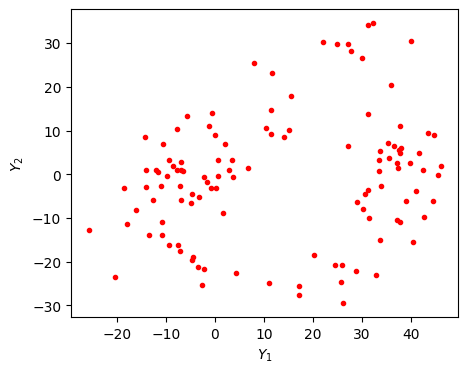

In [101]:
# Ordinary least squares solution
W = inv(X @ X.T) @ X @ Y.T
# predict test data
Ytest = W.T.dot(Xtest)

# plot
fig = plt.figure(figsize=(5,4))
fig.clf()
plt.plot(Ytest[0,:],Ytest[1,:],'r.')
plt.xlabel('$Y_1$')
plt.ylabel('$Y_2$');

## Results: Linear Regression

<div style='text-align:center;'>
<img src='figures/amyo_results.pdf' width='600'/>
</div>

## Results: Linear Regression — Smoothed

<div style='text-align:center;'>
<img src='figures/amyo_results_smoothed.pdf' width='600'/>
</div>

## Non-Linearity 

<table style='margin:auto; border:none;'>
<tr>
<td style='text-align:center; border:none; padding: 0 20px; vertical-align:top;'>
<img src='figures/amyo_nonlinear-1.pdf' width='320'/><br>
<small>Hand position is a <em>non-linear</em> function of muscle activation.</small>
</td>
<td style='text-align:center; border:none; padding: 0 20px; vertical-align:top;'>
<img src='figures/amyo_nonlinear-2.pdf' width='300'/><br>
<small>
Weak muscle activation<br>
$\rightarrow$ True handposition (dashed) <b>over</b>estimated (grey)<br><br>
Strong muscle activation<br>
$\rightarrow$ True handposition <b>under</b>estimated
</small>
</td>
</tr>
</table>

## Linear(ized) Regression

<table style='margin:auto; border:none;'>
<tr>
<td style='text-align:center; border:none; padding: 0 20px; vertical-align:top;'>
<img src='figures/amyo_linearized-1.pdf' width='320'/><br>
<small>Hand position is <em>almost linearly</em> related to the log of muscle activation.</small>
</td>
<td style='text-align:center; border:none; padding: 0 20px; vertical-align:top;'>
<img src='figures/amyo_linearized-2.pdf' width='300'/><br>
<small>
Weak muscle activation<br>
$\rightarrow$ Handposition <em>less</em> <b>under</b>estimated<br><br>
Strong muscle activation<br>
$\rightarrow$ Handposition <em>less</em> <b>over</b>estimated
</small>
</td>
</tr>
</table>

## Smoothed and Log Features

<div style='text-align:center;'>
<img src='figures/amyo_results_log_features_smoothed.pdf' width='600'/>
</div>

# Non-Linear Regression

If non-linearity is not known:

1. **Polynomial Regression** — explicit feature expansion
2. **Random Kitchen Sinks** — randomised basis functions (Rahimi & Recht 2008)

## Polynomial Regression — Theory

<div style='text-align:center;'>

Extend linear regression with **polynomial features** of degree $d$:

$\hat{y} = \beta_0 + \beta_1 x + \beta_2 x^2 + \cdots + \beta_d x^d = \boldsymbol{\phi}(x)^{\top} \boldsymbol{\beta}$

where $\boldsymbol{\phi}(x) = [1,\, x,\, x^2,\, \ldots,\, x^d]^{\top}$ is the **Vandermonde feature map**.

**Key insight:** The model remains *linear in parameters* $\boldsymbol{\beta}$, so the same Normal Equations apply:

$\hat{\boldsymbol{\beta}} = (\boldsymbol{\Phi}^{\top}\boldsymbol{\Phi})^{-1}\boldsymbol{\Phi}^{\top}\mathbf{y}$

where $\boldsymbol{\Phi}$ is the **design matrix** of polynomial features.

</div>

## Polynomial Regression — Pseudocode

**Require:** Data $\mathbf{x} \in \mathbb{R}^{T}$, labels $\mathbf{y} \in \mathbb{R}^{T}$, degree $d$  
**Ensure:** Coefficient vector $\hat{\boldsymbol{\beta}}$

```
1. FEATURE EXPANSION:
      Phi = PolynomialFeatures(degree=d).fit_transform(x)
      # Phi columns: [1, x, x^2, ..., x^d]   shape: T x (d+1)

2. FIT via Normal Equations on expanded features:
      beta_hat = inv(Phi.T @ Phi) @ Phi.T @ y

3. PREDICT:
      Phi_new  = PolynomialFeatures(d).transform(x_new)
      y_hat    = Phi_new @ beta_hat

4. MODEL SELECTION (cross-validation):
      FOR d IN [1, 2, 3, 4, 5]:
          score_d = cross_val_score(pipeline(d), x, y)
      RETURN d* = argmax score_d
```

In [102]:
# Fit polynomial models of degrees 1, 2, 3 on non-linear EMG data
import pandas as pd
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

In [103]:
X = np.random.randn(100,1)
y = np.sin(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.8)

results_poly = {}
for deg in [1, 2, 3]:
    pipe = make_pipeline(
        PolynomialFeatures(degree=deg, include_bias=True),
        LinearRegression()
    )
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    results_poly["Degree {}".format(deg)] = {
        "R2":   round(r2_score(y_test, preds), 4),
        "RMSE": round(np.sqrt(mean_squared_error(y_test, preds)), 4)
    }

pd.DataFrame(results_poly).T

,R2,RMSE
Degree 1,0.7940,0.2847
Degree 2,0.2546,0.5417
Degree 3,0.9808,0.0869


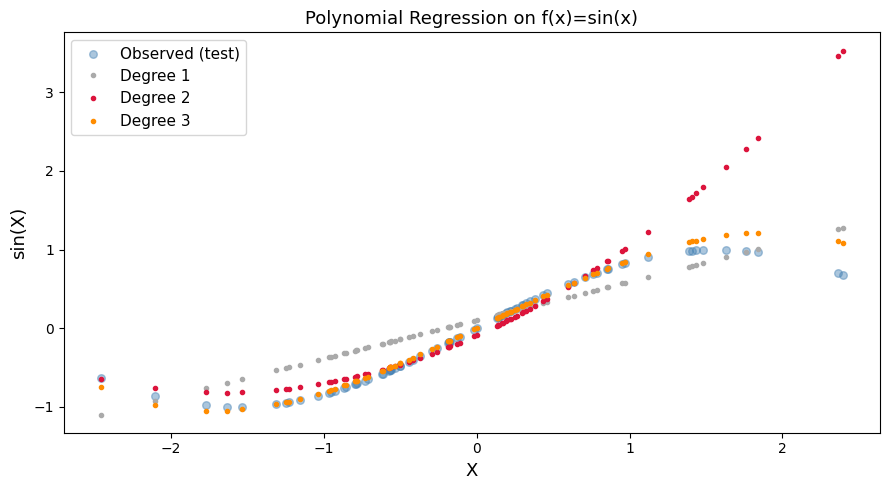

In [104]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(X_test, y_test, alpha=0.45, s=30,
           color='steelblue', label='Observed (test)')

colors = {1: '#aaaaaa', 2: 'crimson', 3: 'darkorange'}
for deg, col in colors.items():
    pipe = make_pipeline(
        PolynomialFeatures(deg, include_bias=True), LinearRegression())
    pipe.fit(X_train, y_train)
    ax.plot(X_test, pipe.predict(X_test), '.',
            color=col, lw=2.2, label='Degree {}'.format(deg))

ax.set_xlabel('X', fontsize=13)
ax.set_ylabel('sin(X)', fontsize=13)
ax.set_title('Polynomial Regression on f(x)=sin(x)', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Time Series

---

**Dataset:** Monthly Airline Passengers 1949–1960  
**Source:** `statsmodels` built-in (Box & Jenkins 1976, classic benchmark)

Approaches:
1. **Linear Autoregression** — OLS on lagged features
2. **SARIMAX** — structured seasonal model overview
3. **Modern methods** — overview & references

## Time Series — Key Concepts

A **time series** $\{y_t\}_{t=1}^{T}$ is a sequence of observations ordered in time.

**Core challenges:**

| Challenge | Description |
|:---|:---|
| **Trend** | Long-term systematic increase or decrease |
| **Seasonality** | Periodic patterns (daily, weekly, yearly) |
| **Non-stationarity** | Mean/variance change over time |
| **Autocorrelation** | $y_t$ depends on $y_{t-1}, y_{t-2}, \ldots$ |

**Key principle:** Past values contain information about future values.

In [105]:
import statsmodels.api as sm
import pandas as pd

# Load airline passengers dataset
data = sm.datasets.get_rdataset('AirPassengers', 'datasets').data
data.columns = ['time', 'passengers']
data['date'] = pd.date_range(start='1949-01', periods=len(data), freq='MS')
ts = data.set_index('date')['passengers']

print("Date range  : {} to {}".format(ts.index.min().date(), ts.index.max().date()))
print("Observations: {}".format(len(ts)))
print(ts.head(6))

Date range  : 1949-01-01 to 1960-12-01
Observations: 144
date
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
1949-06-01    135
Name: passengers, dtype: int64


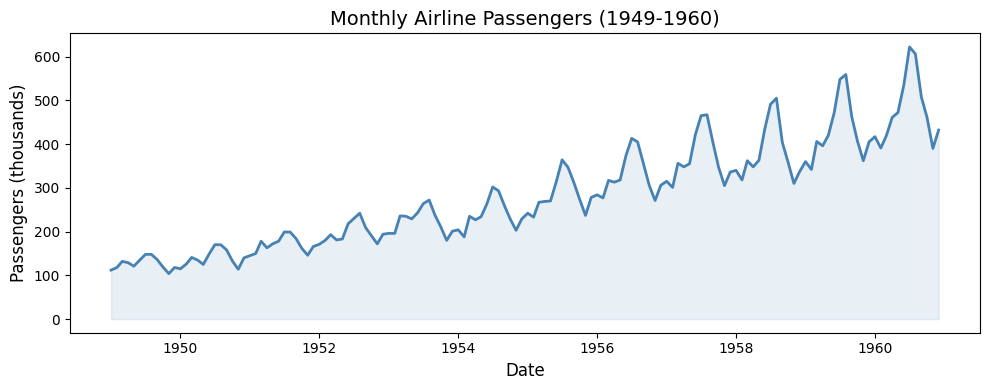

In [106]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ts.index, ts.values, color='steelblue', lw=2)
ax.fill_between(ts.index, ts.values, alpha=0.12, color='steelblue')
ax.set_title('Monthly Airline Passengers (1949-1960)', fontsize=14)
ax.set_ylabel('Passengers (thousands)', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
plt.tight_layout()
plt.show()

## Linear Autoregression — Theory

<div style='text-align:center;'>

**Simplest time series model:** predict $y_t$ from its $p$ most recent past values.

**AR(p) model:**

$y_t = \phi_1 y_{t-1} + \phi_2 y_{t-2} + \cdots + \phi_p y_{t-p} + \varepsilon_t$

In matrix form — identical to ordinary linear regression:

$\mathbf{y} = \boldsymbol{\Phi}^{\top} \mathbf{L} + \boldsymbol{\varepsilon}$

where $\mathbf{L}$ is the **lag matrix** (design matrix of lagged values).

**Solution:** $\hat{\boldsymbol{\phi}} = (\mathbf{L}\mathbf{L}^{\top})^{-1}\mathbf{L}\mathbf{y}^{\top}$ — standard Normal Equations.

</div>

## Linear Autoregression — Pseudocode

**Require:** Time series $y_1, \ldots, y_T$, lag order $p$  
**Ensure:** Autoregressive coefficients $\hat{\boldsymbol{\phi}}$

```
1. PREPROCESSING:
      Apply log-transform if variance grows with level:
      y_log = log(y)

2. BUILD lag design matrix L:
      For t = p+1, ..., T:
          row_t = [ y_{t-1}, y_{t-2}, ..., y_{t-p} ]
      L has shape: (T-p) x p

3. TRAIN/TEST SPLIT:
      Train on L[0 : T_train], Test on L[T_train :]

4. FIT via Normal Equations:
      phi_hat = inv(L.T @ L) @ L.T @ y[p:T_train]

5. FORECAST h steps ahead:
      Iteratively apply: y_hat_t = phi_hat.T @ [y_{t-1},...,y_{t-p}]
```

In [107]:
# Build lag matrix for AR(p) using log-transformed series

def build_lag_matrix(series, p):
    """
    Build design matrix of lagged values.
    Returns X (T-p, p) and y (T-p,).
    """
    vals = series.values
    rows = []
    for t in range(p, len(vals)):
        rows.append(vals[t-p:t][::-1])   # [y_{t-1}, ..., y_{t-p}]
    X_lag = np.array(rows)               # (T-p) x p
    y_lag = vals[p:]                     # (T-p,)
    return X_lag, y_lag, series.index[p:]


p = 13           # 12 monthly lags + 1 for trend
ts_log = np.log(ts)

X_lag, y_lag, idx = build_lag_matrix(ts_log, p)

# Train on first 108 months, test on last 24
split = len(y_lag) - 24
X_tr, X_te = X_lag[:split], X_lag[split:]
y_tr, y_te = y_lag[:split], y_lag[split:]
idx_te = idx[split:]

print("Lag matrix shape (train):", X_tr.shape)
print("Lag matrix shape (test) :", X_te.shape)

Lag matrix shape (train): (107, 13)
Lag matrix shape (test) : (24, 13)


In [108]:
# Fit AR(13) via plain Linear Regression
ar_model = LinearRegression(fit_intercept=True)
ar_model.fit(X_tr, y_tr)

# One-step-ahead predictions on test set
y_pred_ar_log = ar_model.predict(X_te)
y_pred_ar     = np.exp(y_pred_ar_log)
y_te_orig     = np.exp(y_te)

r2_ar   = r2_score(y_te_orig, y_pred_ar)
rmse_ar = np.sqrt(mean_squared_error(y_te_orig, y_pred_ar))

print("AR({}) via Linear Regression (log scale)".format(p))
print("  R2 score : {:.4f}".format(r2_ar))
print("  RMSE     : {:.2f} thousand passengers".format(rmse_ar))

AR(13) via Linear Regression (log scale)
  R2 score : 0.9486
  RMSE     : 16.93 thousand passengers


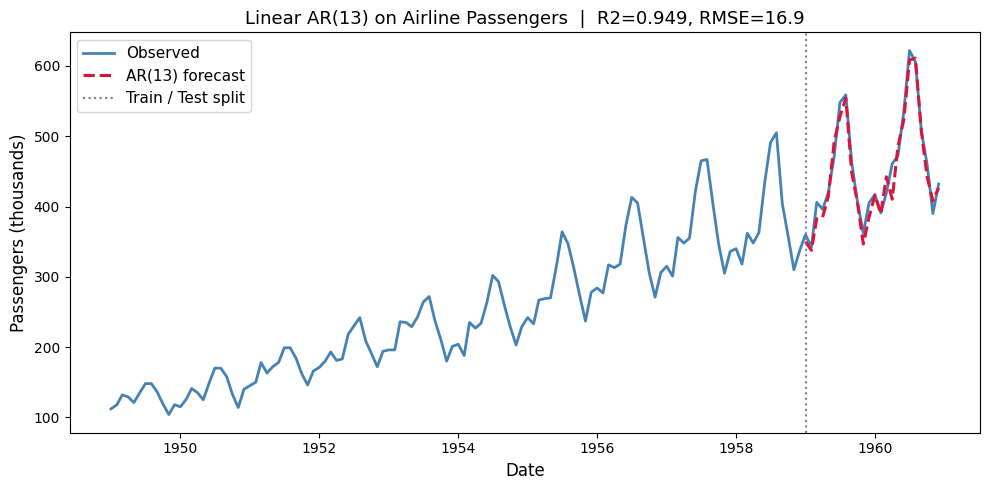

In [109]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ts.index, ts.values,
        color='steelblue', lw=2, label='Observed')
ax.plot(idx_te, y_pred_ar,
        color='crimson', lw=2.2, linestyle='--',
        label='AR({}) forecast'.format(p))
ax.axvline(idx_te[0], color='gray', linestyle=':', lw=1.5,
           label='Train / Test split')
ax.set_title('Linear AR({}) on Airline Passengers  |  '
             'R2={:.3f}, RMSE={:.1f}'.format(p, r2_ar, rmse_ar), fontsize=13)
ax.set_ylabel('Passengers (thousands)', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## SARIMAX — Building Blocks

**SARIMAX** = Seasonal AutoRegressive Integrated Moving Average with eXogenous variables

| Component | Symbol | Meaning |
|:---|:---:|:---|
| AutoRegressive | AR($p$) | $y_t$ depends on $p$ past values |
| Integrated | I($d$) | Difference $d$ times for stationarity |
| Moving Average | MA($q$) | $y_t$ depends on $q$ past error terms |
| Seasonal AR | SAR($P$) | Seasonal autoregression at period $m$ |
| Seasonal MA | SMA($Q$) | Seasonal moving average at period $m$ |
| Exogenous | X | External covariates |

**Notation:** SARIMAX$(p,d,q)(P,D,Q)_m$

## SARIMAX — Mathematical Form

<div style='text-align:center;'>

Using the **backshift operator** $B$ where $B^k y_t = y_{t-k}$:

$\underbrace{\Phi_P(B^m)}_{\text{Seasonal AR}} \underbrace{\phi_p(B)}_{\text{AR}} \underbrace{(1-B)^d}_{\text{Diff}} \underbrace{(1-B^m)^D}_{\text{Seasonal Diff}} y_t = \underbrace{\Theta_Q(B^m)}_{\text{Seasonal MA}} \underbrace{\theta_q(B)}_{\text{MA}} \varepsilon_t$

where $\varepsilon_t \sim \mathcal{N}(0, \sigma^2)$.

**Example — simple ARIMA(1,1,1):**

$(1 - \phi B)(1-B)y_t = (1 + \theta B)\varepsilon_t$

**Parameters** estimated by **Maximum Likelihood** via Kalman Filter.

</div>

## SARIMAX — Objective Function

<div style='text-align:center;'>

Parameters are estimated by **Maximum Likelihood Estimation (MLE)**:

$\mathcal{L}(\boldsymbol{\theta}) = -\frac{T}{2}\ln(2\pi\sigma^2) - \frac{1}{2\sigma^2} \sum_{t=1}^{T} \varepsilon_t^2$

Equivalently, **minimise the negative log-likelihood**:

$-\ell(\boldsymbol{\theta}) = \frac{T}{2}\ln(\sigma^2) + \frac{1}{2\sigma^2}\sum_{t=1}^{T}\varepsilon_t^2$

The **Kalman Filter** efficiently computes the innovations $\varepsilon_t$ for any candidate $\boldsymbol{\theta}$.  
Optimised numerically via **L-BFGS-B** (quasi-Newton gradient method).

</div>

## SARIMAX — Pseudocode

**Require:** Series $y_1,\ldots,y_T$, orders $(p,d,q)(P,D,Q,m)$  
**Ensure:** Fitted parameters $\phi, \theta, \Phi, \Theta, \sigma^2$

```
1. STATIONARITY:
      w_t = (1-B)^d (1-B^m)^D y_t       # apply differencing

2. INITIALISE parameters theta_0 (e.g. via OLS on diff. series)

3. REPEAT until convergence:
      a. Run Kalman Filter on w_t
            --> compute innovations e_t = w_t - E[w_t | w_{t-1},...]
      b. Evaluate log-likelihood L(theta)
      c. Update theta via L-BFGS-B gradient step

4. FORECAST h steps ahead:
      Use final Kalman state + parameter estimates
      Invert differencing to recover original scale
```

## Linear AR vs SARIMAX — Comparison

| Property | Linear AR (OLS) | SARIMAX |
|:---|:---|:---|
| **Model class** | AR($p$) via OLS | AR + I + MA + Seasonal |
| **Objective** | Least squares | Maximum likelihood (MLE) |
| **Solution** | Closed form (Normal Equations) | Iterative (Kalman + L-BFGS) |
| **Stationarity** | Assumed or pre-processed | Handled via differencing |
| **Seasonality** | Via seasonal lags only | Explicit seasonal operators |
| **Uncertainty** | Not native | Confidence intervals from MLE |
| **Interpretability** | High | Moderate |

**Key reference:** Box & Jenkins (1976); Hamilton (1994)

## Modern Time Series Methods

Beyond SARIMAX, the field has advanced substantially:

| Method | Type | Key Feature | Reference |
|:---|:---|:---|:---|
| **Prophet** | Decomposition | Trend + Fourier seasonality, changepoints | Taylor & Letham (2018) |
| **DeepAR** | RNN (LSTM) | Probabilistic, multi-series | Salinas et al. (2020) |
| **N-BEATS** | Deep Learning | Interpretable, no feature engineering | Oreshkin et al. (2020) |
| **Temporal Fusion Transformer** | Transformer | Multi-horizon + covariates | Lim et al. (2021) |
| **PatchTST** | Transformer | Patch-based self-supervised | Nie et al. (2023) |
| **TimesNet** | CNN | 2D temporal variation modelling | Wu et al. (2023) |

## Time Series Modelling — Summary

| Property | Linear AR | SARIMAX | Modern (DL) |
|:---|:---|:---|:---|
| **Complexity** | Low | Medium | High |
| **Interpretability** | High | High | Low–Medium |
| **Data requirement** | Small | Small–Medium | Large |
| **Seasonality** | Implicit (lags) | Explicit | Learned |
| **Uncertainty** | None | Native CI | Probabilistic (some) |
| **Speed** | Very fast | Fast | Slow (train) |

**Recommendation:**  
- Start with **Linear AR / SARIMAX** as baseline  
- Upgrade to **deep learning** only if scale and data justify it

## Overall Summary

| Method | Objective | Optimisation | Best For |
|:---|:---|:---|:---|
| **Linear Regression** | $\|\mathbf{y}-\mathbf{w}^{\top}\mathbf{X}\|^2$ | Normal Equations (exact) | Linear EMG decoding |
| **Polynomial Regression** | same on $\boldsymbol{\Phi}$ | Normal Equations (exact) | Smooth non-linearities |
| **Random Kitchen Sinks** | same on $\mathbf{Z}$ | Normal Equations (exact) | Large-scale non-linear |
| **Linear AR** | $\|\mathbf{y}-\boldsymbol{\phi}^{\top}\mathbf{L}\|^2$ | Normal Equations (exact) | Short stationary series |
| **SARIMAX** | Neg. log-likelihood | Kalman + L-BFGS | Seasonal structured series |
| **Deep TS models** | Task-specific | SGD / Adam | Large-scale forecasting |

> **Key insight:** All regression-based methods minimise prediction error — the difference lies in *what feature space* they operate in and *what constraints* are placed on the solution.

## References

- Legendre, A.M. (1805). *Nouvelles methodes pour la determination des orbites des cometes*.
- Gauss, C.F. (1809). *Theoria Motus Corporum Coelestium*.
- Box, G.E.P. & Jenkins, G.M. (1976). *Time Series Analysis: Forecasting and Control*. Holden-Day.
- Hamilton, J.D. (1994). *Time Series Analysis*. Princeton University Press.
- Rahimi, A. & Recht, B. (2008). Random features for large-scale kernel machines. *NeurIPS*.
- Hahne, J.M. et al. (2014). Linear and nonlinear regression techniques for simultaneous and proportional myoelectric control. Neural Systems and Rehabilitation Engineering, IEEE Transactions
- Taylor, S.J. & Letham, B. (2018). Forecasting at scale. *The American Statistician*, 72(1).
- Salinas, D. et al. (2020). DeepAR: Probabilistic forecasting with autoregressive RNNs. *IJF*, 36(3).
- Oreshkin, B. et al. (2020). N-BEATS: Neural basis expansion for time series. *ICLR*.
- Lim, B. et al. (2021). Temporal Fusion Transformers for interpretable forecasting. *IJF*, 37(4).
- Nie, Y. et al. (2023). A time series is worth 64 words: PatchTST. *ICLR*.
- Wu, H. et al. (2023). TimesNet: Temporal 2D-variation modeling. *ICLR*.